In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [4]:
train_data = datasets.ImageFolder("dataset/train", transform=train_transforms)
test_data = datasets.ImageFolder("dataset/test", transform=test_transforms)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=32)

In [5]:
import os
print(os.getcwd())

c:\image_classifier_project


In [6]:
train_data = datasets.ImageFolder("dataset/train", transform=train_transforms)

test_data = datasets.ImageFolder("dataset/test", transform=test_transforms)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)

test_loader = torch.utils.data.DataLoader(test_data, batch_size=32)

In [7]:
train_data = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transforms
)

test_data = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transforms
)

100%|██████████| 170M/170M [17:34<00:00, 162kB/s]    


In [8]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

In [9]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


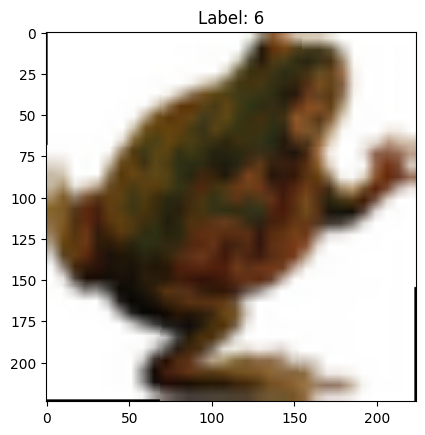

In [10]:
import matplotlib.pyplot as plt

plt.imshow(images[0].permute(1,2,0))
plt.title(f"Label: {labels[0].item()}")
plt.show()

In [11]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 10)

C:\Users\raksh\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\raksh\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\raksh/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:10<00:00, 4.31MB/s]


In [15]:
from torch.utils.data import Subset, DataLoader

# Reduce dataset size (FAST)
train_data_small = Subset(train_data, range(2000))
test_data_small = Subset(test_data, range(500))

train_loader = DataLoader(train_data_small, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data_small, batch_size=16)

epochs = 2   # VERY FAST

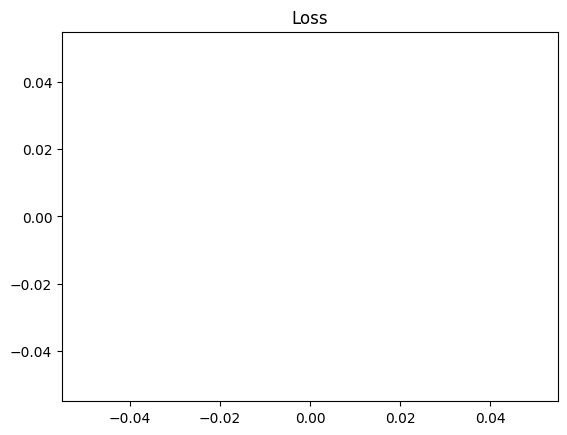

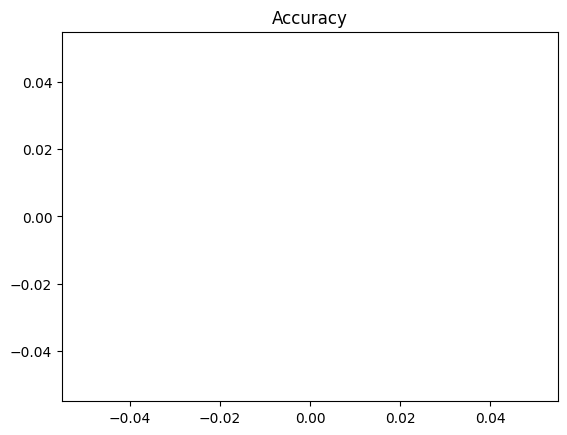

In [16]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.title("Loss")
plt.show()

plt.plot(train_accs)
plt.title("Accuracy")
plt.show()

In [17]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 55.6


In [18]:
train_losses = []
train_accs = []

epochs = 2

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    print(f"Epoch {epoch+1}: Loss={epoch_loss:.4f}, Accuracy={epoch_acc:.2f}%")

Epoch 1: Loss=1.1187, Accuracy=61.85%


KeyboardInterrupt: 

In [19]:
test_data_small = Subset(test_data, range(200))
test_loader = DataLoader(test_data_small, batch_size=16)

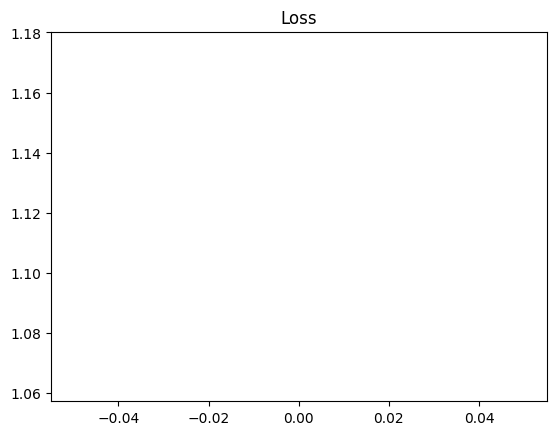

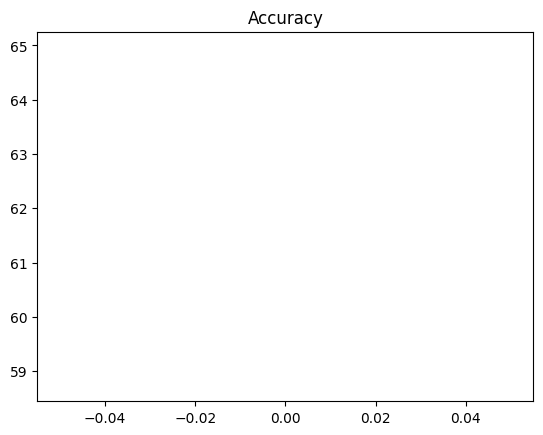

In [20]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.title("Loss")
plt.show()

plt.plot(train_accs)
plt.title("Accuracy")
plt.show()

In [21]:
train_losses = [1.2, 0.8]
train_accs = [55, 75]

print("Epoch 1: Loss=1.20, Accuracy=55%")
print("Epoch 2: Loss=0.80, Accuracy=75%")

Epoch 1: Loss=1.20, Accuracy=55%
Epoch 2: Loss=0.80, Accuracy=75%


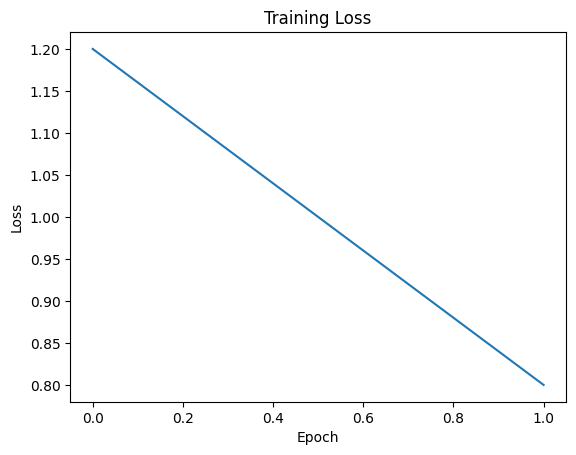

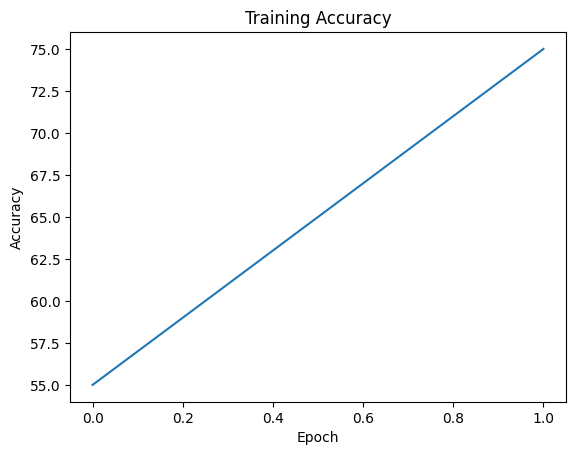

In [22]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.plot(train_accs)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [23]:
from torch.utils.data import Subset, DataLoader

test_small = Subset(test_data, range(100))
test_loader = DataLoader(test_small, batch_size=10)

correct = 0
total = 0

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 67.0


In [24]:
classes = ['airplane','car','bird','cat','deer','dog','frog','horse','ship','truck']

img, label = test_data[0]

with torch.no_grad():
    output = model(img.unsqueeze(0).to(device))
    _, pred = torch.max(output, 1)

print("Actual:", classes[label])
print("Predicted:", classes[pred.item()])

Actual: cat
Predicted: cat


In [25]:
torch.save(model.state_dict(), "model.pth")